# Ekman Emotion Classification — Single-Stage E2E

**Pipeline:**
```
Text → [7-class multi-label] → anger / disgust / fear / joy / sadness / surprise / neutral
```

| | E2E |
|---|---|
| **Task** | Multi-label: 6 emotions + neutral (7 classes) |
| **Recommended** | DeBERTa-v3 |
| **Loss** | Three-tier Per-Class ASL |
| **Imbalance** | severe (joy/fear ≈ 10×, neutral ≈ 14k) → 3-tier strategy |

**Output structure:**
```
<run_base_dir>/run_e2e/
  deberta/                ← first run
    checkpoints/best.pth
    logs/training_log.csv
    logs/config.txt
    results/              ← report, metrics, charts
  deberta_2/              ← second run (no overwrite)
```

## 0. Setup

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
!git clone https://github.com/Kylndlih3147/NLP_Emotion_Group_14.git

Cloning into 'NLP_Emotion_Group_14'...
remote: Enumerating objects: 228, done.
remote: Counting objects: 100% (228/228), done.
remote: Compressing objects: 100% (151/151), done.
remote: Total 228 (delta 108), reused 174 (delta 66), pack-reused 0 (from 0)
Receiving objects: 100% (228/228), 5.26 MiB | 26.52 MiB/s, done.
Resolving deltas: 100% (108/108), done.


In [21]:
!pip install torch transformers scikit-learn pandas numpy matplotlib tqdm pyyaml -q

In [22]:
import os, sys
import torch

PROJECT_ROOT = os.path.abspath('.')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device: cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [23]:
cd /content/NLP_Emotion_Group_14/end-to-end

/content/NLP_Emotion_Group_14/end-to-end


In [24]:
from src.utils import load_config

CONFIG_PATH = 'config/config.yaml'
cfg = load_config(CONFIG_PATH)

print(f"run_base_dir : {cfg['run_base_dir']}")
print(f"Model        : {cfg['e2e']['model']['name']}")
print(f"Loss         : {cfg['e2e']['training']['loss']}")

run_base_dir : /content/drive/MyDrive
Model        : electra
Loss         : focal_bce


## 1. Data Exploration

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(os.path.join(cfg['data']['data_dir'], cfg['data']['train_file']))
emotions = ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']
counts   = df[emotions].sum().sort_values(ascending=False)

n_emotion = (df[emotions].sum(axis=1) > 0).sum()
n_neutral = len(df) - n_emotion
median    = counts.median()

print(f'Total samples : {len(df):,}')
print(f'has_emotion   : {n_emotion:,} ({n_emotion/len(df)*100:.1f}%)')
print(f'neutral       : {n_neutral:,} ({n_neutral/len(df)*100:.1f}%)')
print(f'\nClass counts (all 7, sorted):')
all_counts = dict(counts)
all_counts['neutral'] = n_neutral
for name, c in sorted(all_counts.items(), key=lambda x: -x[1]):
    tier = 'very_rare' if c < median/3 else 'rare' if c < median else 'common'
    print(f'  {name:<12}: {int(c):>6}  [{tier}]')
print(f'\nmedian={median:.0f}  joy/fear ratio={counts["joy"]/counts["fear"]:.1f}×')

Total samples : 50,248
has_emotion   : 35,751 (71.1%)
neutral       : 14,497 (28.9%)

Class counts (all 7, sorted):
  joy         :  19794  [common]
  neutral     :  14497  [common]
  anger       :   7813  [common]
  surprise    :   5418  [common]
  sadness     :   5392  [rare]
  disgust     :   3366  [rare]
  fear        :   1941  [rare]

median=5405  joy/fear ratio=10.2×


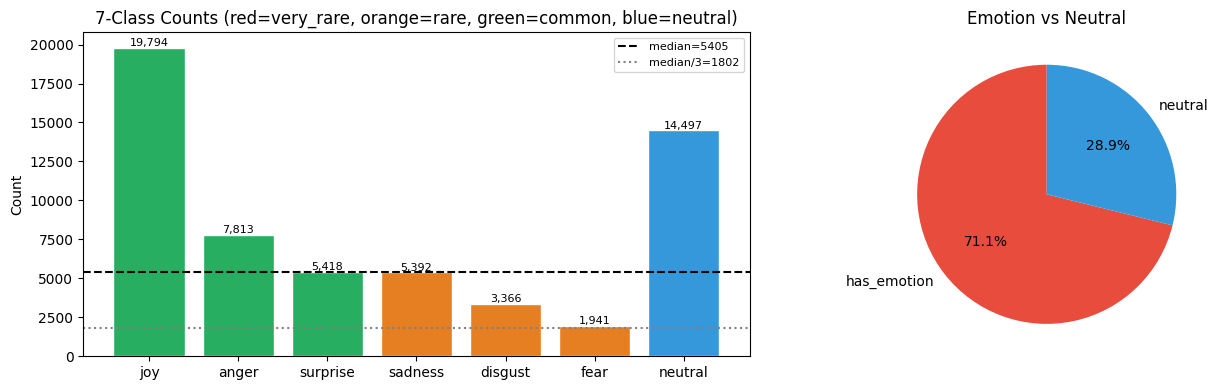

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# All 7 classes bar chart
all_names = list(counts.index) + ['neutral']
all_vals  = list(counts.values) + [n_neutral]
colors7   = ['#c0392b' if v < median/3 else '#e67e22' if v < median else '#27ae60'
             if n != 'neutral' else '#3498db'
             for n, v in zip(all_names, all_vals)]

axes[0].bar(all_names, all_vals, color=colors7, edgecolor='white')
axes[0].axhline(median,   color='black', linestyle='--', label=f'median={median:.0f}')
axes[0].axhline(median/3, color='gray',  linestyle=':',  label=f'median/3={median/3:.0f}')
axes[0].set_title('7-Class Counts (red=very_rare, orange=rare, green=common, blue=neutral)')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)
for i, (n, v) in enumerate(zip(all_names, all_vals)):
    axes[0].text(i, v + 100, f'{int(v):,}', ha='center', fontsize=8)

# Pie: emotion vs neutral
axes[1].pie([n_emotion, n_neutral], labels=['has_emotion', 'neutral'],
            colors=['#e74c3c', '#3498db'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Emotion vs Neutral')

plt.tight_layout()
plt.show()

## 2. Training

**Task:** 7-class multi-label (6 emotions + neutral), ALL samples  
**Recommended model:** DeBERTa-v3  

**Three-tier treatment:**
| Tier | Classes | Aug copies | Sampler boost | pos_weight scale | ASL γ- |
|------|---------|-----------|--------------|-----------------|--------|
| very_rare | fear | ×4 | ×5 | ^2.0 | 0.5 |
| rare | disgust, neutral | ×2 | ×3 | ^1.5 | 1.0 |
| common | anger, joy, sadness, surprise | ×0 | ×1 | ^1.0 | 2.0 |

In [27]:
import yaml

CONFIG_PATH = 'config/config.yaml'
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

# -----------------------------------------------------------------------------
# Output
# -----------------------------------------------------------------------------
cfg['run_base_dir'] = "/content/drive/MyDrive"  # đường dẫn lưu kết quả

# -----------------------------------------------------------------------------
# Data
# -----------------------------------------------------------------------------
cfg['data']['data_dir']   = "data/"
cfg['data']['train_file'] = "data1_train.csv"
cfg['data']['val_file']   = "data1_val.csv"
cfg['data']['test_file']  = "data1_test.csv"

cfg['data']['auto_split']  = True
cfg['data']['val_ratio']   = 0.10
cfg['data']['test_ratio']  = 0.10
cfg['data']['max_length']  = 128
cfg['data']['seed']        = 42
cfg['data']['num_workers'] = 2

# -----------------------------------------------------------------------------
# Model
# -----------------------------------------------------------------------------
cfg['e2e']['model']['name']    = "electra"  # deberta / roberta / electra / bert
cfg['e2e']['model']['dropout'] = 0.2

# -----------------------------------------------------------------------------
# Training
# -----------------------------------------------------------------------------
cfg['e2e']['training']['epochs']                  = 20
cfg['e2e']['training']['batch_size']              = 16   # giảm xuống 16 nếu OOM
cfg['e2e']['training']['lr']                      = 2.0e-5
cfg['e2e']['training']['weight_decay']            = 0.05
cfg['e2e']['training']['optimizer']               = "adamw"
cfg['e2e']['training']['scheduler']               = "cosine_warmup"
cfg['e2e']['training']['warmup_ratio']            = 0.10
cfg['e2e']['training']['early_stopping_patience'] = 5
cfg['e2e']['training']['threshold']               = 0.5
cfg['e2e']['training']['loss']                    = "focal_bce"

# -----------------------------------------------------------------------------
# Tier thresholds
# -----------------------------------------------------------------------------
cfg['e2e']['training']['very_rare_divisor'] = 3.0
cfg['e2e']['training']['rare_divisor']      = 1.0

# -----------------------------------------------------------------------------
# Synonym augmentation
# -----------------------------------------------------------------------------
cfg['e2e']['training']['augment_rare']         = True
cfg['e2e']['training']['aug_copies_very_rare'] = 2
cfg['e2e']['training']['aug_copies_rare']      = 1
cfg['e2e']['training']['aug_copies_common']    = 0

# -----------------------------------------------------------------------------
# Weighted sampler
# -----------------------------------------------------------------------------
cfg['e2e']['training']['use_weighted_sampler'] = True
cfg['e2e']['training']['sampler_power']        = 0.7
cfg['e2e']['training']['boost_very_rare']      = 2.0
cfg['e2e']['training']['boost_rare']           = 1.5
cfg['e2e']['training']['boost_common']         = 1.0

# -----------------------------------------------------------------------------
# pos_weight scale per tier
# -----------------------------------------------------------------------------
cfg['e2e']['training']['pw_scale_very_rare'] = 2.0
cfg['e2e']['training']['pw_scale_rare']      = 1.5
cfg['e2e']['training']['pw_scale_common']    = 1.0

# -----------------------------------------------------------------------------
# Per-class ASL gammas
# -----------------------------------------------------------------------------
cfg['e2e']['training']['asl_gamma_pos_very_rare'] = 0.0
cfg['e2e']['training']['asl_gamma_neg_very_rare'] = 0.5
cfg['e2e']['training']['asl_clip_very_rare']      = 0.0

cfg['e2e']['training']['asl_gamma_pos_rare'] = 0.5
cfg['e2e']['training']['asl_gamma_neg_rare'] = 1.0
cfg['e2e']['training']['asl_clip_rare']      = 0.0

cfg['e2e']['training']['asl_gamma_pos_common'] = 1.0
cfg['e2e']['training']['asl_gamma_neg_common'] = 2.0
cfg['e2e']['training']['asl_clip_common']      = 0.0

# Save overrides back to yaml so train.py reads them
with open(CONFIG_PATH, 'w') as f:
    yaml.dump(cfg, f, default_flow_style=False, allow_unicode=True)

print(f"Model  : {cfg['e2e']['model']['name']}")
print(f"Epochs : {cfg['e2e']['training']['epochs']}")
print(f"Batch  : {cfg['e2e']['training']['batch_size']}")
print(f"Loss   : {cfg['e2e']['training']['loss']}")

Model  : electra
Epochs : 20
Batch  : 16
Loss   : focal_bce


In [11]:
from src.train import train

result = train(config_path=CONFIG_PATH)

RUN_DIR = result['run_dir']
print(f'\nRun directory: {RUN_DIR}')
print(f'Best epoch   : {result["best_epoch"]}')
for k, v in result['best_metrics'].items():
    print(f'  {k}: {v:.4f}')


  New run  : electra
  Path     : /content/drive/MyDrive/run_e2e/electra
[train] Device=cuda  AMP=True (float16)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Epoch 10/20 [  val]:   0%|          | 0/395 [00:00<?, ?batch/s]

Epoch  10/20  tr_loss=0.0080  val_loss=0.1984  micro_f1=0.6827  macro_f1=0.6368  w_f1=0.6825  lr=1.17e-05  [500s]


Epoch 11/20 [train]:   0%|          | 0/3684 [00:00<?, ?batch/s]

Epoch 11/20 [  val]:   0%|          | 0/395 [00:00<?, ?batch/s]

Epoch  11/20  tr_loss=0.0064  val_loss=0.2079  micro_f1=0.6754  macro_f1=0.6396  w_f1=0.6794  lr=1.00e-05  [500s]
[train] Early stopping at epoch 11 (5 epochs no improve).

[train] Done — best val_macro_f1=0.6417 @ epoch 6
        micro_f1=0.6781
        macro_f1=0.6417
        weighted_f1=0.6845
[train] log → /content/drive/MyDrive/run_e2e/electra/logs/training_log.csv

Run directory: /content/drive/MyDrive/run_e2e/electra
Best epoch   : 6
  micro_f1: 0.6781
  macro_f1: 0.6417
  weighted_f1: 0.6845


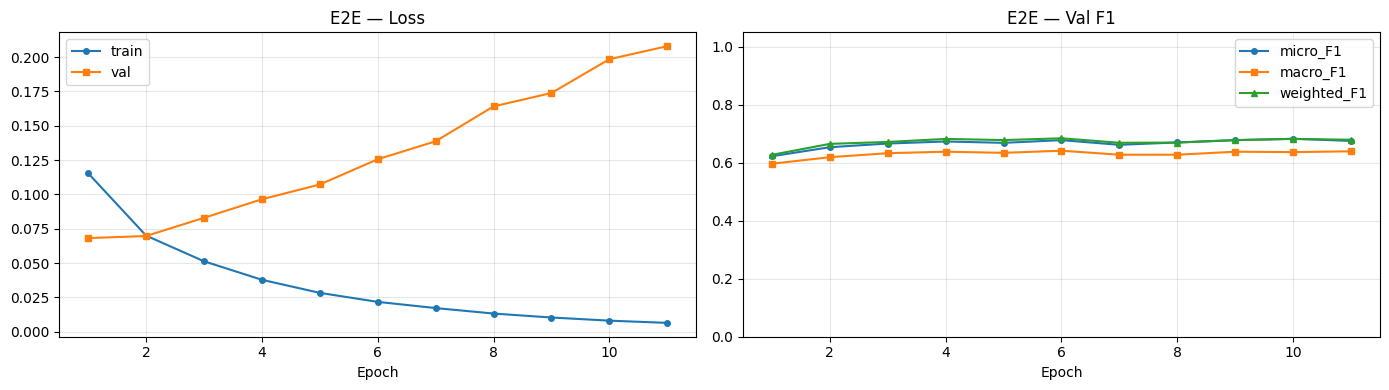

In [12]:
log = pd.read_csv(result['log_path'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(log.epoch, log.train_loss, label='train', marker='o', ms=4)
ax1.plot(log.epoch, log.val_loss,   label='val',   marker='s', ms=4)
ax1.set_title('E2E — Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(log.epoch, log.val_micro_f1,    label='micro_F1',    marker='o', ms=4)
ax2.plot(log.epoch, log.val_macro_f1,    label='macro_F1',    marker='s', ms=4)
ax2.plot(log.epoch, log.val_weighted_f1, label='weighted_F1', marker='^', ms=4)
ax2.set_title('E2E — Val F1')
ax2.set_xlabel('Epoch')
ax2.set_ylim(0, 1.05)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Evaluate on Test Set

In [28]:
from src.test import evaluate

metrics = evaluate(config_path=CONFIG_PATH, run_dir=RUN_DIR)

print(f'Micro  F1    : {metrics["micro_f1"]:.4f}')
print(f'Macro  F1    : {metrics["macro_f1"]:.4f}')
print(f'Weighted F1  : {metrics["weighted_f1"]:.4f}')
print(f'Hamming Loss : {metrics["hamming"]:.4f}')
print(f'Subset Acc   : {metrics["subset_accuracy"]:.4f}')


  Evaluation — 7 Classes


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraModel LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
discriminator_predictions.dense.weight            | UNEXPECTED |  | 
electra.embeddings_project.bias                   | UNEXPECTED |  | 
discriminator_predictions.dense.bias              | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 
electra.embeddings_project.weight                 | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[test] Loaded checkpoint  epoch=6  val_loss=nan
[DataLoader] backbone=electra
[DataLoader] Tier breakdown (train counts):
    anger       :   7813  [common]
    disgust     :   3366  [rare]
    fear        :   1941  [rare]
    joy         :  19794  [common]
    sadness     :   5392  [rare]
    surprise    :   5418  [common]
    neutral     :  14497  [common]
[DataLoader] Aug tier=rare      : 8681 samples × 1 copies → +8681
[DataLoader] Train: 58929 | Val: 6312 | Test: 8686
[DataLoader] pos_weight:
    anger       : 4.60
    disgust     : 11.63
    fear        : 21.27
    joy         : 1.80
    sadness     : 6.70
    surprise    : 9.14
    neutral     : 3.06

[test] Per-class threshold search on val set...


Val:   0%|          | 0/395 [00:00<?, ?batch/s]

  anger       : t=0.55  val_F1=0.6106
  disgust     : t=0.50  val_F1=0.6273
  fear        : t=0.70  val_F1=0.6608
  joy         : t=0.40  val_F1=0.8264
  sadness     : t=0.65  val_F1=0.6192
  surprise    : t=0.55  val_F1=0.5518
  neutral     : t=0.40  val_F1=0.6561


Test:   0%|          | 0/543 [00:00<?, ?batch/s]


  Micro  F1    : 0.7060
  Macro  F1    : 0.6690
  Weighted F1  : 0.7076
  Hamming Loss : 0.1135
  Subset Acc   : 0.5245
              precision    recall  f1-score   support

       anger       0.66      0.69      0.67      1787
     disgust       0.67      0.69      0.68      1219
        fear       0.67      0.71      0.69       578
         joy       0.82      0.84      0.83      3699
     sadness       0.64      0.67      0.66      1412
    surprise       0.48      0.55      0.51       800
     neutral       0.60      0.69      0.64      1883

   micro avg       0.69      0.73      0.71     11378
   macro avg       0.65      0.69      0.67     11378
weighted avg       0.69      0.73      0.71     11378
 samples avg       0.71      0.75      0.71     11378

[test] Saved → /content/drive/MyDrive/run_e2e/electra/results
Micro  F1    : 0.7060
Macro  F1    : 0.6690
Weighted F1  : 0.7076
Hamming Loss : 0.1135
Subset Acc   : 0.5245


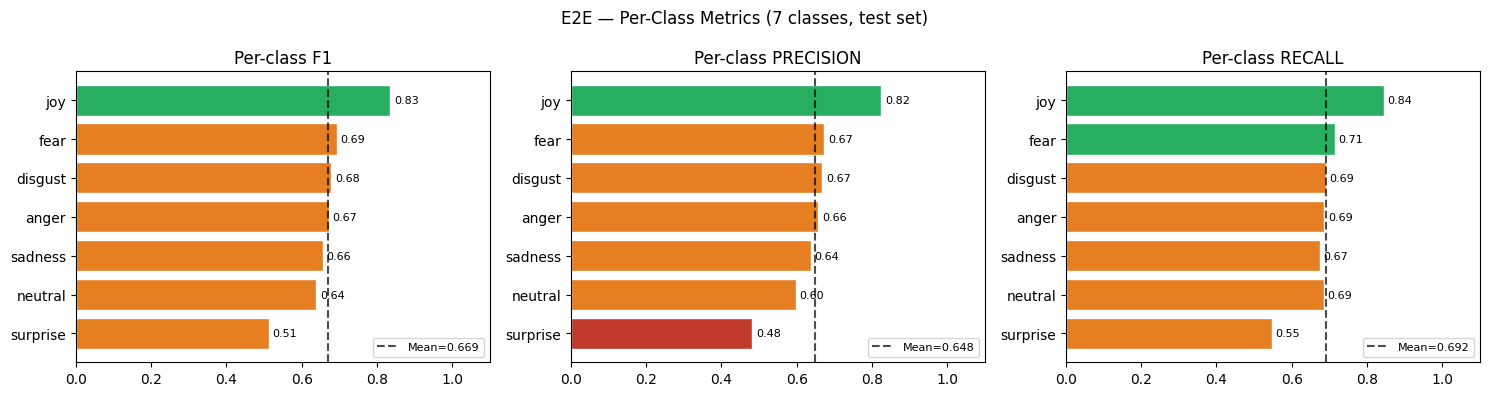

,threshold,precision,recall,f1,support
class,,,,,
surprise,0.55,0.4818,0.5463,0.5120,800
neutral,0.40,0.5974,0.6856,0.6385,1883
sadness,0.65,0.6366,0.6749,0.6552,1412
anger,0.55,0.6574,0.6861,0.6714,1787
disgust,0.50,0.6680,0.6899,0.6788,1219
fear,0.70,0.6726,0.7145,0.6930,578
joy,0.40,0.8243,0.8448,0.8344,3699


In [14]:
pc = pd.read_csv(os.path.join(metrics['out_dir'], 'per_class.csv'))
pc = pc.set_index('class').sort_values('f1')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['f1', 'precision', 'recall']):
    colors = ['#c0392b' if v < 0.5 else '#e67e22' if v < 0.7 else '#27ae60'
              for v in pc[col]]
    bars = ax.barh(pc.index, pc[col], color=colors, edgecolor='white')
    ax.set_xlim(0, 1.1)
    ax.set_title(f'Per-class {col.upper()}')
    ax.axvline(pc[col].mean(), color='black', linestyle='--', alpha=0.7,
               label=f'Mean={pc[col].mean():.3f}')
    ax.legend(fontsize=8)
    for bar, v in zip(bars, pc[col]):
        ax.text(v+0.01, bar.get_y()+bar.get_height()/2,
                f'{v:.2f}', va='center', fontsize=8)

plt.suptitle('E2E — Per-Class Metrics (7 classes, test set)', fontsize=12)
plt.tight_layout()
plt.show()
display(pc)


─── PR Curves ───


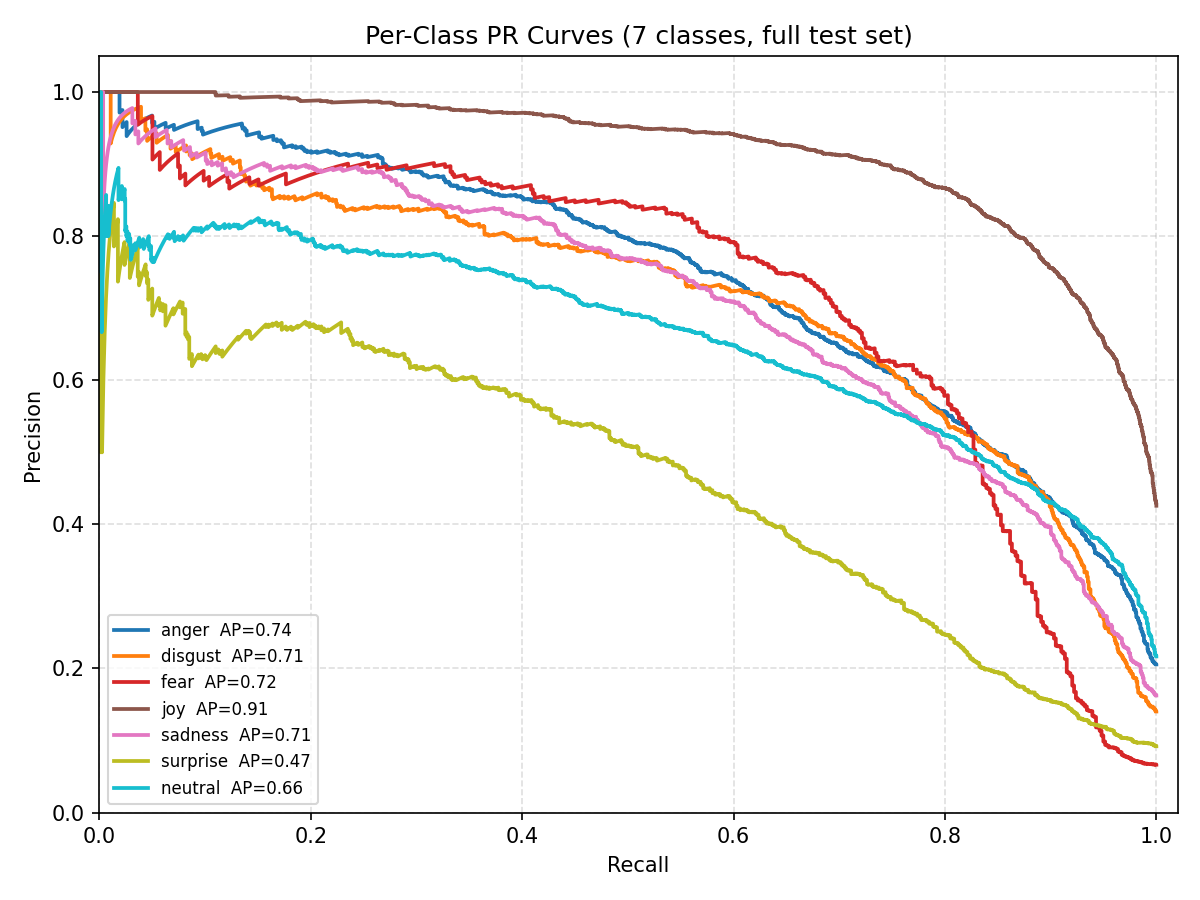


─── Aggregated Confusion Matrix ───


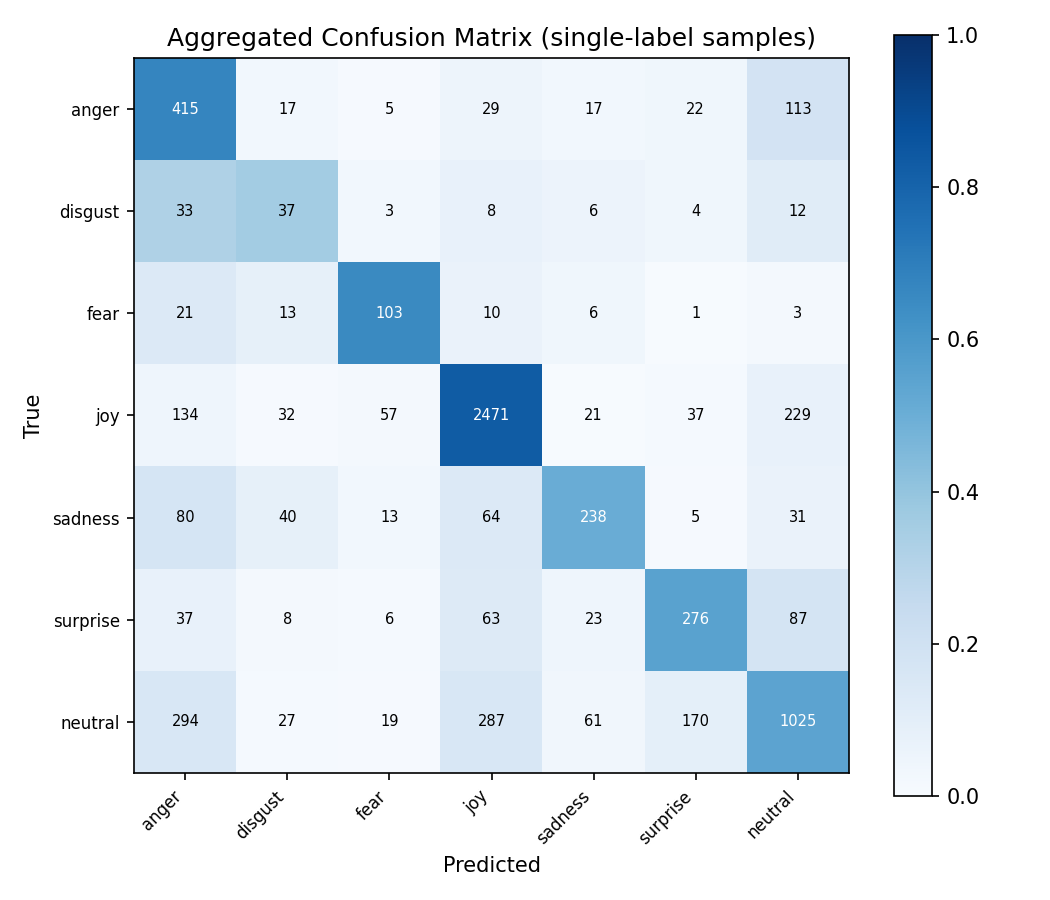


─── Per-Class Confusion Matrices ───


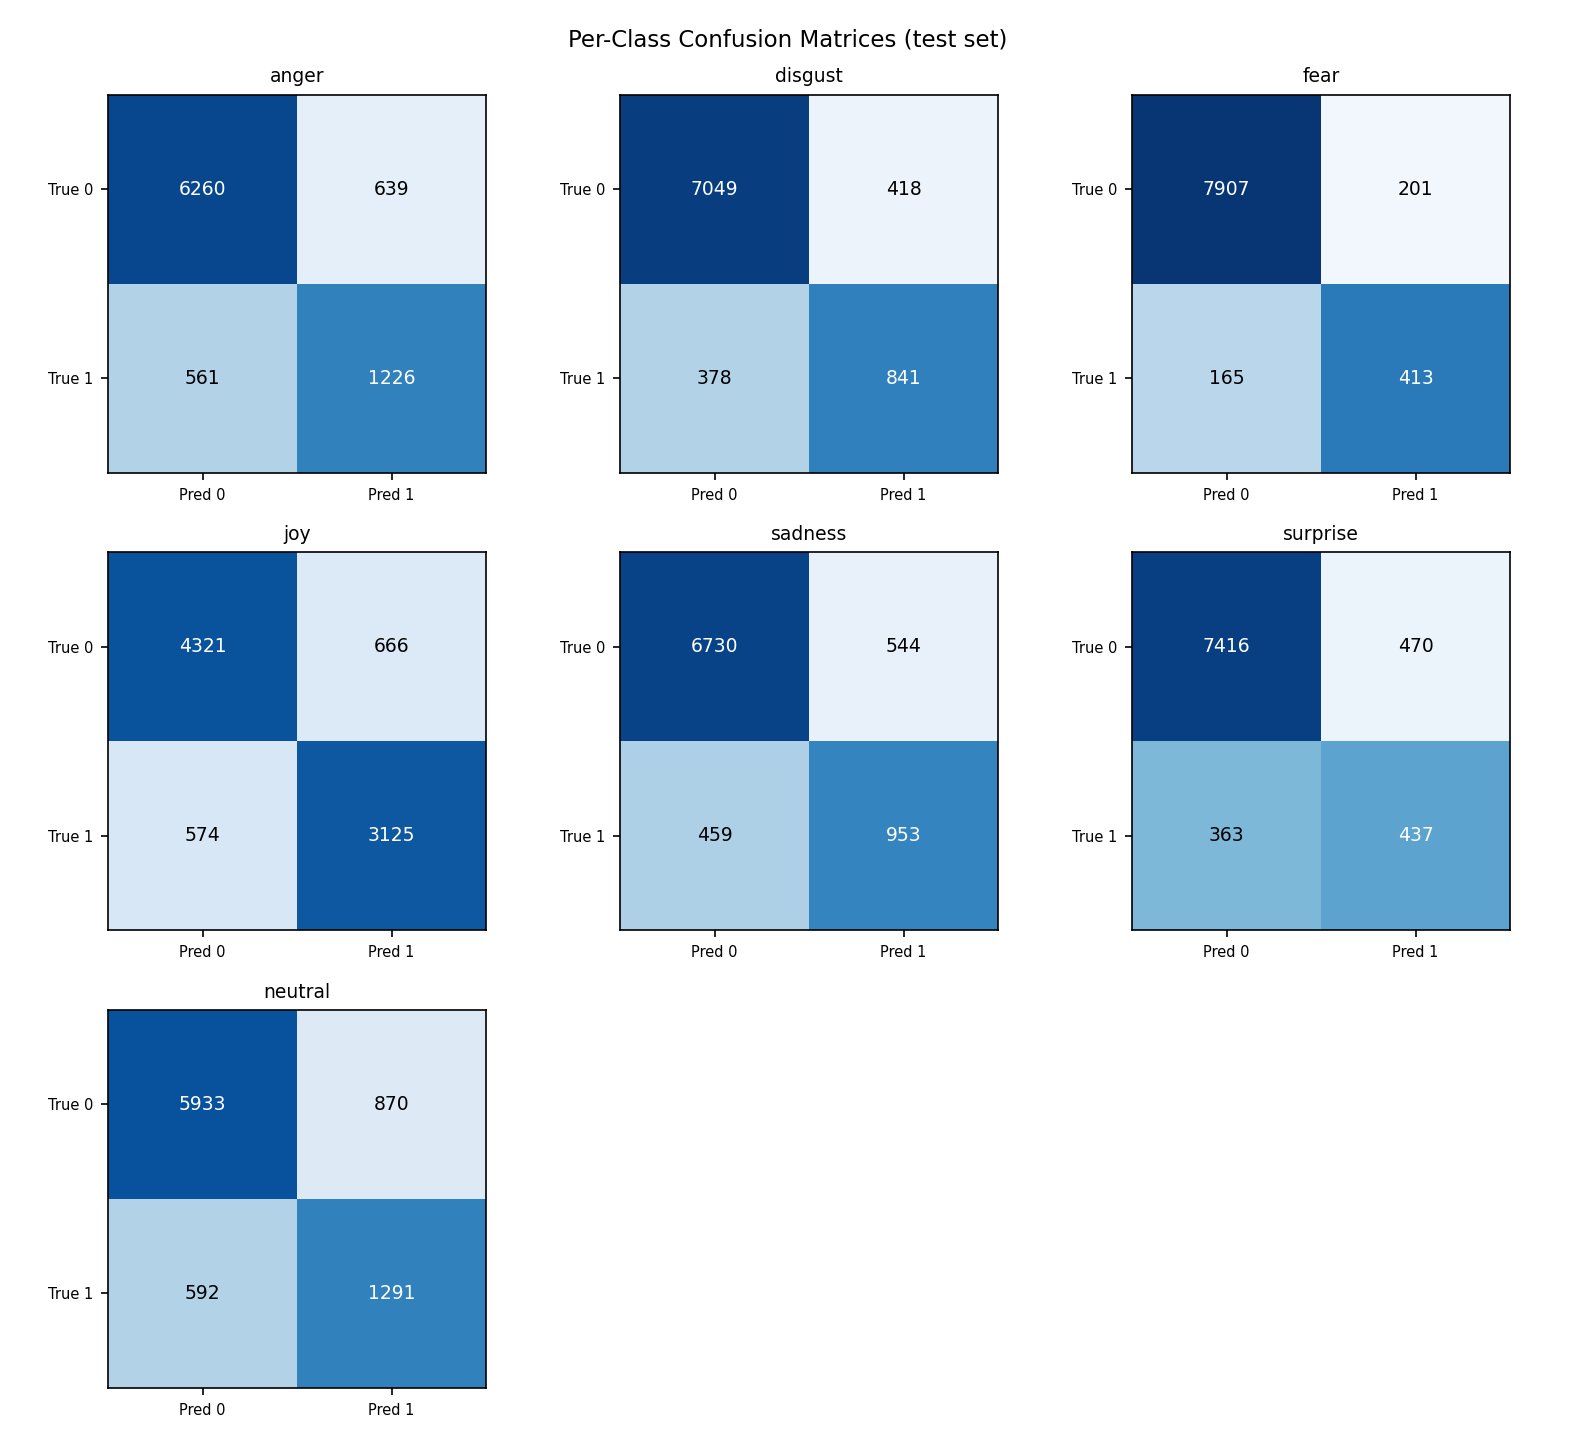


─── Probability Heatmap ───


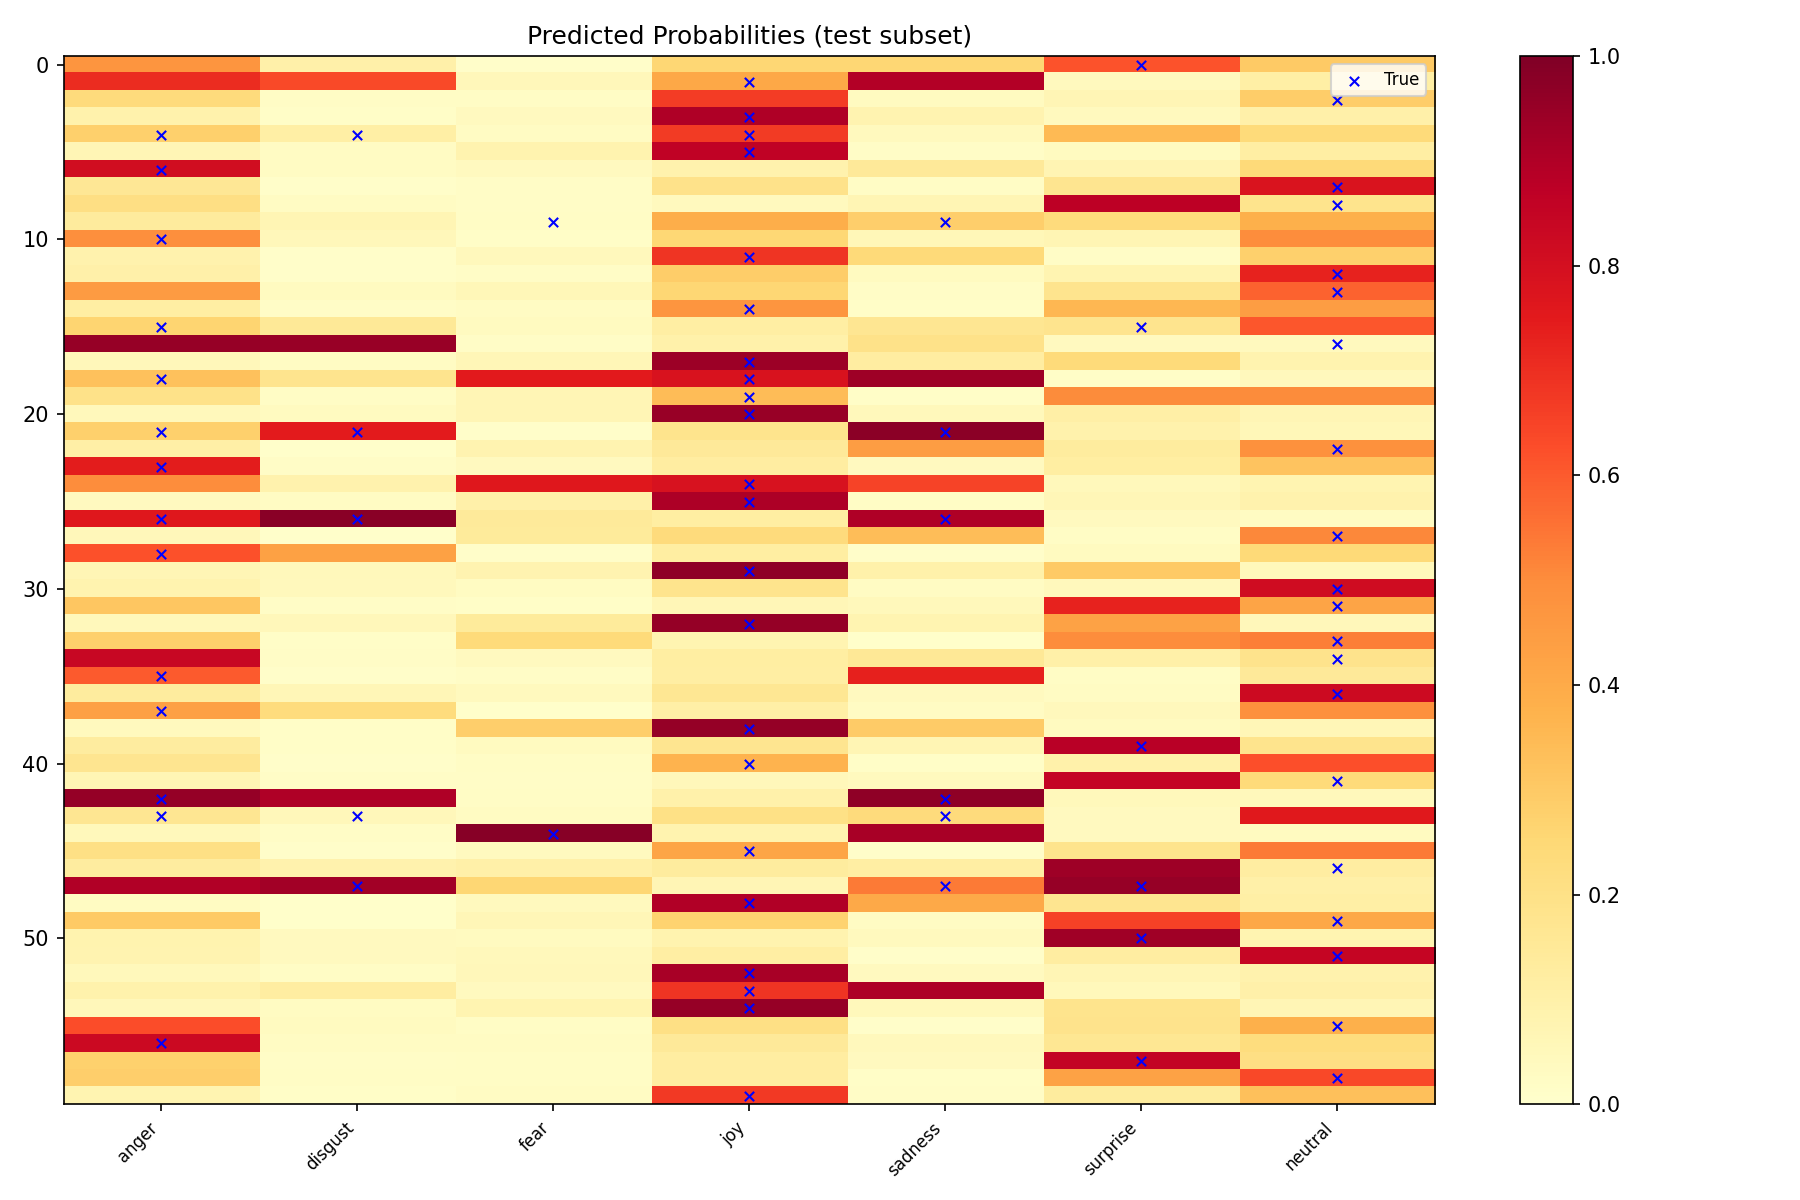


─── Optimal Thresholds ───


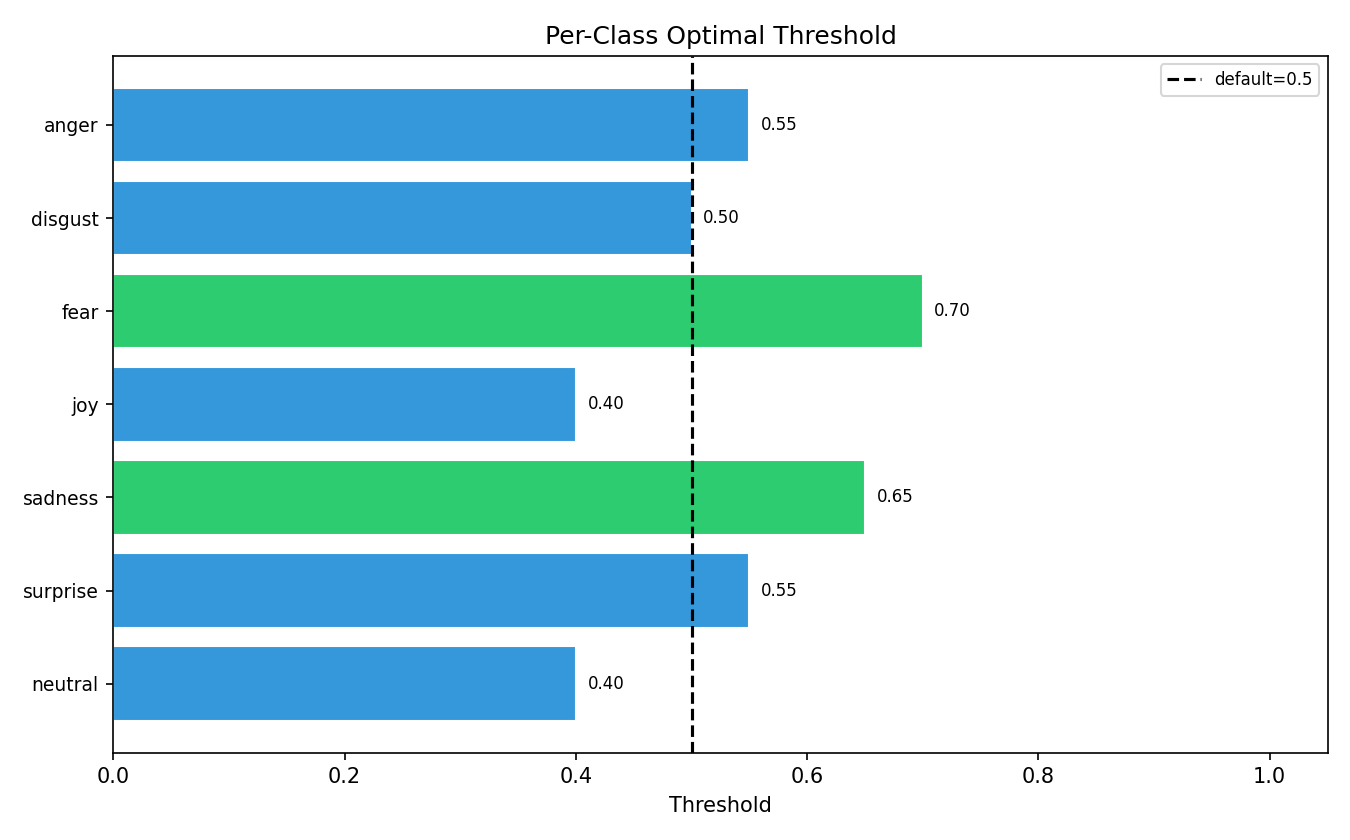

In [15]:
from IPython.display import Image, display as ipy_display

plots = [
    ('pr_curve.png',            'PR Curves'),
    ('confusion_aggregate.png', 'Aggregated Confusion Matrix'),
    ('confusion.png',           'Per-Class Confusion Matrices'),
    ('heatmap.png',             'Probability Heatmap'),
    ('thresholds.png',          'Optimal Thresholds'),
]

for fname, title in plots:
    path = os.path.join(metrics['out_dir'], fname)
    if os.path.isfile(path):
        print(f'\n─── {title} ───')
        ipy_display(Image(path))

## 4. Results Summary

In [16]:
print('=' * 62)
print(f'  Run : {result["run_name"]}')
print(f'  Dir : {RUN_DIR}')
print('=' * 62)
print(f'\n E2E — 7 Classes ({cfg["e2e"]["model"]["name"]})')
print(f'   Micro F1     : {metrics["micro_f1"]:.4f}')
print(f'   Macro F1     : {metrics["macro_f1"]:.4f}')
print(f'   Weighted F1  : {metrics["weighted_f1"]:.4f}')
print(f'   Hamming Loss : {metrics["hamming"]:.4f}')
print(f'   Subset Acc   : {metrics["subset_accuracy"]:.4f}')
print('=' * 62)

print('\n Per-class F1:')
pc_sorted = pc.sort_values('f1', ascending=False)
for name, row in pc_sorted.iterrows():
    bar = '█' * int(row['f1'] * 20)
    print(f'  {name:<12}: {row["f1"]:.4f}  {bar}')

  Run : electra
  Dir : /content/drive/MyDrive/run_e2e/electra

 E2E — 7 Classes (electra)
   Micro F1     : 0.7060
   Macro F1     : 0.6690
   Weighted F1  : 0.7076
   Hamming Loss : 0.1135
   Subset Acc   : 0.5245

 Per-class F1:
  joy         : 0.8344  ████████████████
  fear        : 0.6930  █████████████
  disgust     : 0.6788  █████████████
  anger       : 0.6714  █████████████
  sadness     : 0.6552  █████████████
  neutral     : 0.6385  ████████████
  surprise    : 0.5120  ██████████


## 5. Inference on New Texts

In [17]:
import torch
from src.train import build_model
from src.dataloader import BACKBONE_REGISTRY, CLASS_NAMES
from transformers import AutoTokenizer

model_name = cfg['e2e']['model']['name']
ckpt = torch.load(os.path.join(RUN_DIR, 'checkpoints', 'best.pth'),
                  map_location=device, weights_only=False)

model = build_model(cfg['e2e'], num_labels=ckpt['num_labels']).to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()

tokenizer = AutoTokenizer.from_pretrained(BACKBONE_REGISTRY[model_name]['pretrained'])
best_ts   = metrics['best_thresholds']   # per-class thresholds từ val set
max_len   = cfg['data']['max_length']

def predict(text):
    enc = tokenizer(text, max_length=max_len, padding='max_length',
                    truncation=True, return_tensors='pt')
    with torch.no_grad():
        logits = model(enc['input_ids'].to(device),
                       enc['attention_mask'].to(device))
    probs = torch.sigmoid(logits).float().cpu().numpy()[0]
    preds = (probs >= best_ts).astype(int)
    detected = {CLASS_NAMES[i]: float(probs[i])
                for i in range(len(CLASS_NAMES)) if preds[i] == 1}
    if not detected:
        top = CLASS_NAMES[int(probs.argmax())]
        detected = {top: float(probs.max())}
    print(f'  [{text[:70]}]')
    for name, p in sorted(detected.items(), key=lambda x: -x[1]):
        print(f'    → {name:<12}: {p:.3f}  {"█"*int(p*20)}')
    print()

print('Model loaded. Ready for inference.')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraModel LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
discriminator_predictions.dense.weight            | UNEXPECTED |  | 
electra.embeddings_project.bias                   | UNEXPECTED |  | 
discriminator_predictions.dense.bias              | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 
electra.embeddings_project.weight                 | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded. Ready for inference.


In [18]:
test_sentences = [
    "I am so happy today, everything went perfectly!",
    "This is absolutely disgusting, I can't believe they did that.",
    "I'm really scared about what might happen next.",
    "The weather is nice today.",
    "I feel so angry and disappointed at the same time.",
    "Wow, I did not expect that at all — completely shocked!",
    "I miss her so much, it still hurts.",
]

for s in test_sentences:
    predict(s)

  [I am so happy today, everything went perfectly!]
    → joy         : 0.948  ██████████████████

  [This is absolutely disgusting, I can't believe they did that.]
    → disgust     : 0.962  ███████████████████

  [I'm really scared about what might happen next.]
    → fear        : 0.986  ███████████████████

  [The weather is nice today.]
    → joy         : 0.878  █████████████████

  [I feel so angry and disappointed at the same time.]
    → sadness     : 0.951  ███████████████████
    → anger       : 0.893  █████████████████

  [Wow, I did not expect that at all — completely shocked!]
    → surprise    : 0.940  ██████████████████

  [I miss her so much, it still hurts.]
    → sadness     : 0.950  ███████████████████

